In [3]:
# Solar Power Generation - Regression

## 1. Introduction
# The objective of this project is to develop machine learning regression models
# for predicting solar power generation using the Solar Power Generation dataset.
# The project includes data exploration, preprocessing, feature engineering,
# model training, model comparison, hyperparameter tuning, and evaluation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
generation_1 = pd.read_csv("../data/solar/Plant_1_Generation_Data.csv")
weather_1 = pd.read_csv("../data/solar/Plant_1_Weather_Sensor_Data.csv")

generation_2 = pd.read_csv("../data/solar/Plant_2_Generation_Data.csv")
weather_2 = pd.read_csv("../data/solar/Plant_2_Weather_Sensor_Data.csv")

print("Plant 1 Generation:", generation_1.shape)
print("Plant 1 Weather:", weather_1.shape)
print("Plant 2 Generation:", generation_2.shape)
print("Plant 2 Weather:", weather_2.shape)

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


In [4]:
# First 5 rows of each dataset

print("Plant 1 Generation:")
display(generation_1.head())

print("\nPlant 1 Weather:")
display(weather_1.head())

print("\nPlant 2 Generation:")
display(generation_2.head())

print("\nPlant 2 Weather:")
display(weather_2.head())

Plant 1 Generation:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0



Plant 1 Weather:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0



Plant 2 Generation:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07



Plant 2 Weather:


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [5]:
# Dataset Information

print("===== Plant 1 Generation Info =====")
generation_1.info()

print("\n===== Plant 1 Weather Info =====")
weather_1.info()

===== Plant 1 Generation Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  object 
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  object 
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 3.7+ MB

===== Plant 1 Weather Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   object 
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   object 
 3   AMBIENT_TEMPERATURE  

In [6]:
# Descriptive Statistics

print("===== Plant 1 Generation Statistics =====")
display(generation_1.describe())

print("\n===== Plant 1 Weather Statistics =====")
display(weather_1.describe())

===== Plant 1 Generation Statistics =====


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06



===== Plant 1 Weather Statistics =====


,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.0,3182.000000,3182.000000,3182.000000
mean,4135001.0,25.531606,31.091015,0.228313
std,0.0,3.354856,12.261222,0.300836
min,4135001.0,20.398505,18.140415,0.000000
25%,4135001.0,22.705182,21.090553,0.000000
50%,4135001.0,24.613814,24.618060,0.024653
75%,4135001.0,27.920532,41.307840,0.449588
max,4135001.0,35.252486,65.545714,1.221652


In [7]:
# Missing Value Analysis

print("Missing values in Plant 1 Generation:")
display(generation_1.isnull().sum())

print("\nMissing values in Plant 1 Weather:")
display(weather_1.isnull().sum())

print("\nTotal missing values:")
print("Generation:", generation_1.isnull().sum().sum())
print("Weather:", weather_1.isnull().sum().sum())

Missing values in Plant 1 Generation:


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


Missing values in Plant 1 Weather:


DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


Total missing values:
Generation: 0
Weather: 0


In [11]:
### Observation

#No missing values were found in the selected datasets. Therefore, no missing-value imputation was required.

In [8]:
# Duplicate Analysis

print("Duplicate rows in Plant 1 Generation:",
      generation_1.duplicated().sum())

print("Duplicate rows in Plant 1 Weather:",
      weather_1.duplicated().sum())

Duplicate rows in Plant 1 Generation: 0
Duplicate rows in Plant 1 Weather: 0


In [9]:
### Observation

#Duplicate records were checked to prevent repeated observations from affecting the classification models.

Numerical features:
['PLANT_ID', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']


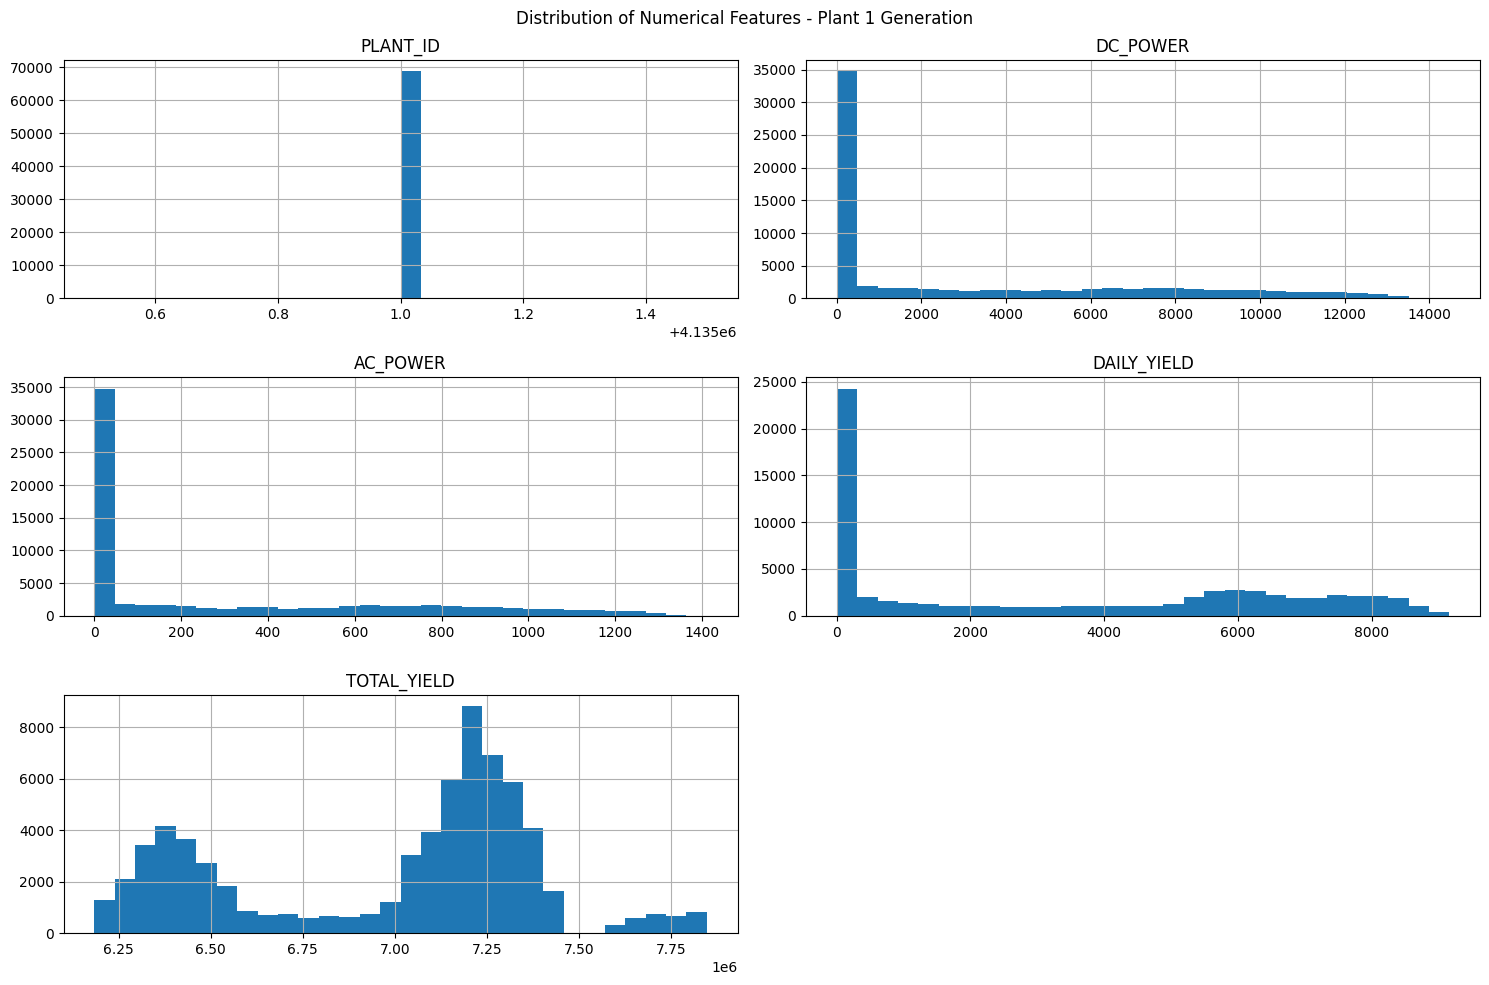

In [10]:
# Feature Distribution Plots

numeric_columns = generation_1.select_dtypes(include=np.number).columns

print("Numerical features:")
print(numeric_columns.tolist())

generation_1[numeric_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features - Plant 1 Generation")
plt.tight_layout()
plt.show()

Numerical weather features:
['PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


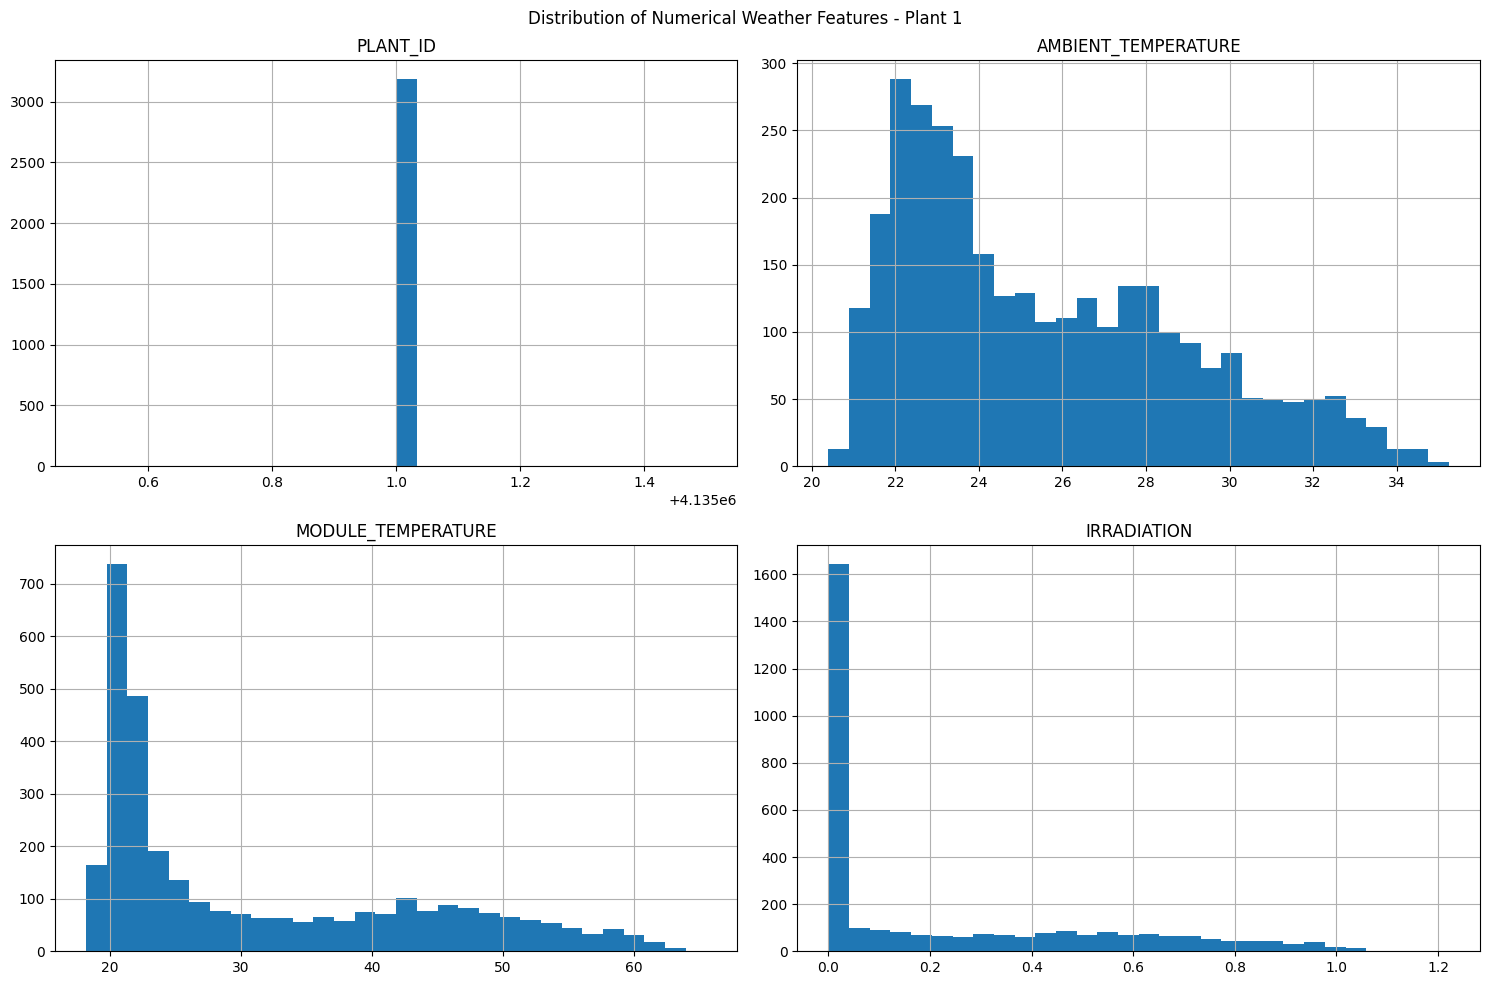

In [11]:
# Weather Feature Distribution Plots

weather_numeric = weather_1.select_dtypes(include=np.number).columns

print("Numerical weather features:")
print(weather_numeric.tolist())

weather_1[weather_numeric].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Weather Features - Plant 1")
plt.tight_layout()
plt.show()

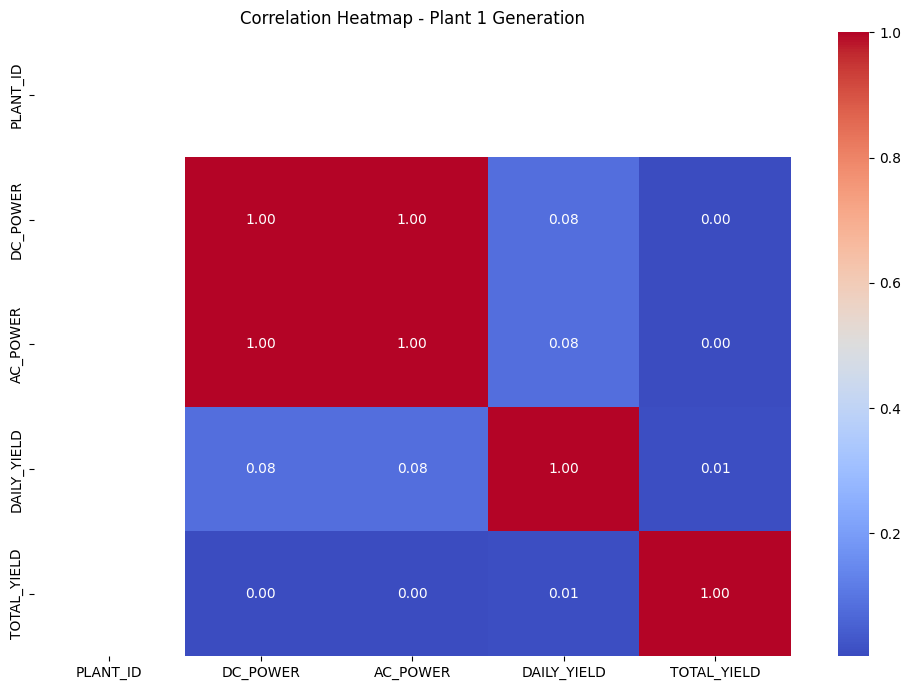

In [12]:
# Correlation Heatmap - Generation Data

plt.figure(figsize=(10, 7))

correlation_matrix = generation_1[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Plant 1 Generation")
plt.tight_layout()
plt.show()

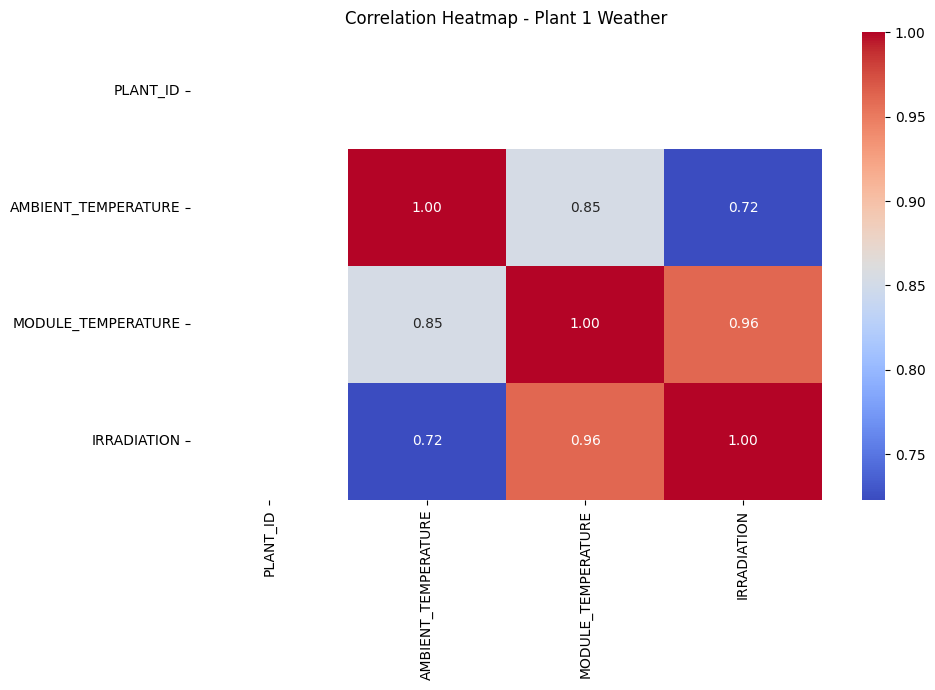

In [13]:
# Correlation Heatmap - Weather Data

plt.figure(figsize=(10, 7))

weather_correlation = weather_1[weather_numeric].corr()

sns.heatmap(
    weather_correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Plant 1 Weather")
plt.tight_layout()
plt.show()

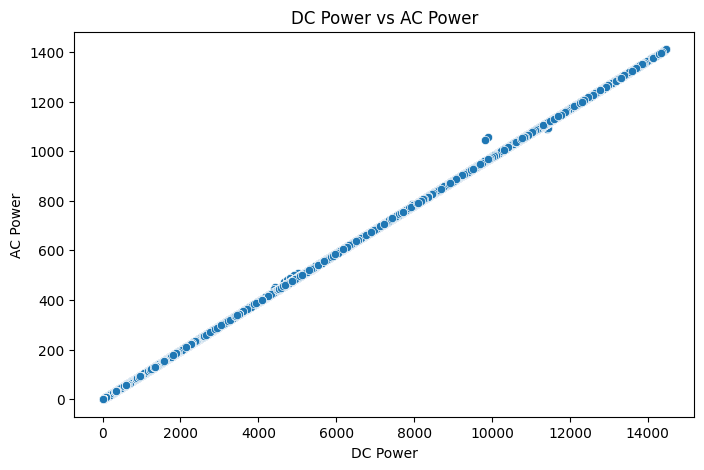

In [14]:
# Feature-Target Relationship: DC Power vs AC Power

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=generation_1,
    x="DC_POWER",
    y="AC_POWER"
)

plt.title("DC Power vs AC Power")
plt.xlabel("DC Power")
plt.ylabel("AC Power")
plt.show()

In [ ]:
## EDA Observations

# - The distribution plots show the spread and variation of the numerical features in the dataset.
# - The correlation heatmap helps identify the strength and direction of relationships between the numerical variables.
# - The DC Power vs AC Power scatter plot shows a very strong positive relationship between DC Power and AC Power.
# - As DC Power increases, AC Power also increases almost proportionally, indicating that DC Power is an important feature for predicting AC Power.
# - The EDA provides useful insights into the relationships between the features and helps guide the preprocessing and model-building stages.

In [15]:
## 3. Data Cleaning and Preprocessing

df = generation_1.copy()

print("Original shape:", df.shape)
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Original shape: (68778, 7)
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
Duplicate rows: 0


Missing Value Handling: The dataset was thoroughly checked, and no missing values were found. Therefore, the data was complete and required no missing-value treatment.

In [16]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (68778, 7)


Duplicate Handling:
Duplicate records were checked and removed. No duplicate rows were present in the dataset.

In [17]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])

print(df["DATE_TIME"].dtype)
df["hour"] = df["DATE_TIME"].dt.hour
df["day"] = df["DATE_TIME"].dt.day
df["month"] = df["DATE_TIME"].dt.month
df["day_of_week"] = df["DATE_TIME"].dt.dayofweek

datetime64[ns]


C:\Users\HP\AppData\Local\Temp\ipykernel_20296\2285204978.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"])


In [18]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,0,15,5,4
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,0,15,5,4
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,0,15,5,4
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,0,15,5,4
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,0,15,5,4


In [19]:
df.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000,68778.000000,68778.000000,68778.000000
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,11.567216,15.762133,5.518567,2.991160
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,0.000000,1.000000,5.000000,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,6.000000,9.000000,5.000000,1.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,12.000000,16.000000,6.000000,3.000000
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,17.000000,23.000000,6.000000,5.000000
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,23.000000,31.000000,6.000000,6.000000
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,6.862477,8.554765,0.499659,2.058307
